## __Multiple Schemas__

Typically, all graph nodes communicate with a single schema.

Also, this single schema contains the graph's input and output keys / channels.

__Objective__ :-\
But, there are cases where we may want a bit more control over this:

* Internal nodes may pass information that is not required in the graph's input / output.

* We may also want to use different input / output schemas for the graph. The output might, for example, only contain a single relevant output key.



### Private State
Case of passing private state between nodes.

This is useful for anything needed as part of the intermediate working logic of the graph, but not relevant for the overall graph input or output.

We'll define an __`OverallState`__ and a __`PrivateState`__.

`node_2` uses `PrivateState` as input, but writes out to `OverallState`.

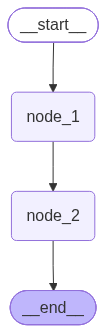

In [1]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    foo: int

class PrivateState(TypedDict):
    baz: int

def node_1(state: OverallState) -> PrivateState:
    print("---Node 1---")
    return {"baz": state['foo'] + 1}

def node_2(state: PrivateState) -> OverallState:
    print("---Node 2---")
    return {"foo": state['baz'] + 1}

# Build graph
builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
graph.invoke({"foo" : 5})

---Node 1---
---Node 2---


{'foo': 7}

In [ ]:
graph.invoke({"foo" : 5})

---Node 1---
---Node 2---


{'foo': 7}

`baz` is only included in `PrivateState`.

`node_2` uses `PrivateState` as __input__, but writes __out__ to `OverallState`.

`Input`: foo = 5 enters the graph execution context.\
`node_1`: Reads foo (5) --> calculates 5 + 1 --> outputs baz = 6.\
`node_2`: Reads baz (6) --> calculates 6 + 1 --> outputs foo = 7.\
`Output`: Final graph state returns foo = 7.

So, we can see that _baz is excluded from the graph output because it is not in OverallState_.

### Input / Output Schema
By default, StateGraph takes in a single schema and all nodes are expected to communicate with that schema.

However, it is also possible to _define explicit input and output schemas for a graph_.

In these cases, we often define an "internal" schema that contains all keys relevant to graph operations.

But we use specific `input` and `output` schemas to constrain the input and output.


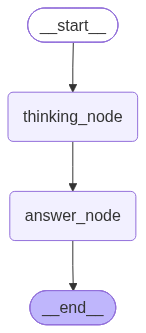

In [9]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: OverallState):
    return {"answer": "bye", "notes": "... Master name is Abdullah"}

def answer_node(state: OverallState):
    return {"answer": "Good Bye! Abdullah"}

graph = StateGraph(OverallState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"question" : "Hieee"})

{'question': 'Hieee',
 'answer': 'Good Bye! Abdullah',
 'notes': '... Master name is Abdullah'}

Now, let's use a specific input and output schema with our graph.

Here, `input / output schemas` perform _filtering on what keys are permitted on the input and output of the graph_.

In addition, we can use a type hint `state: InputState` to specify the _input schema_ of each of our nodes.

This is important when the graph is using multiple schemas.

We use type hints below to, for example, show that the output of `answer_node` will be filtered to `OutputState`.

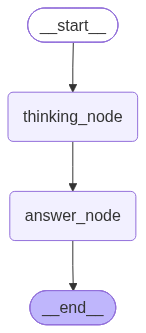

{'answer': 'Good Bye! Abdullah'}

In [11]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "Bye", "notes": "... Master name is Abdullah"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "Good Bye! Abdullah"}

graph = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question":"Hello world!"})

We can see the `output` schema constrains the output to only the `answer` key.